# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [ ]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [ ]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [ ]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [ ]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [ ]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [ ]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [ ]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [ ]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [ ]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipython-input-2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [ ]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [ ]:
model(Variable(xx))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

In [ ]:

# ─────────────────────────────────────────────────────────

# ATIVIDADE 3 — listas para rastrear a evolução dos pesos
w0_list = []
w1_list = []

num_epochs = 100
learning_rate = 0.5

for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred = model(inputs)

    # cálculo da função de perda (MSE)
    loss = torch.mean((y_pred - target)**2)

    # backward propagation - cálculo automático do gradiente
    loss.backward()

    # ATIVIDADE 3: salva os pesos ANTES de atualizá-los
    # .item() extrai o valor escalar do tensor
    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    # gradiente descendente: w = w - lr * grad
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem dos gradientes para a próxima época
    # (PyTorch acumula gradientes, então é obrigatório zerar)
    model.weight.grad.data.zero_()

    # verbose — usando loss.data (ATIVIDADE 1)
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'.format(epoch+1, num_epochs, loss.data))

Epoch[20/100], loss: 0.022983
Epoch[40/100], loss: 0.021432
Epoch[60/100], loss: 0.021207
Epoch[80/100], loss: 0.021175
Epoch[100/100], loss: 0.021170


## Avaliação

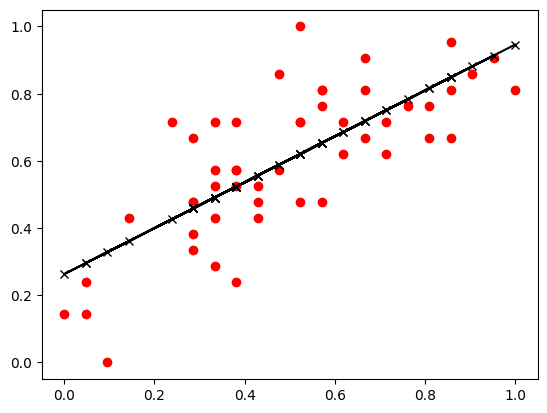

In [ ]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Acessando os parâmetros

In [ ]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

### Parâmetros ótimos, solução analítica

In [ ]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

## Exercício 1 — Por que `loss.data`?

Em PyTorch, qualquer tensor que resulta de operações sobre parâmetros
da rede possui `requires_grad=True`: ele carrega internamente um **grafo
computacional** que registra todas as operações feitas até ali (o histórico
que o `loss.backward()` usa para calcular gradientes por backpropagation).

| Expressão | O que é | Quando usar |
|---|---|---|
| `loss` | Tensor com grafo (requires_grad=True) | Para chamar `.backward()` |
| `loss.data` | Tensor "cru", sem grafo | Para imprimir / comparar valores |
| `loss.item()` | Float Python puro | Forma recomendada hoje |

Imprimir `loss` diretamente em versões antigas do PyTorch gerava warnings.
O `.data` desanexa o valor do grafo, retornando apenas o número — seguro
para exibição sem interferir no fluxo do autograd.

## Exercício 2 — Perda com pesos treinados

In [ ]:
# ATIVIDADE 2 — MSE com os pesos já treinados
# Usamos torch.no_grad() para desabilitar o cálculo de gradientes:
# em modo de avaliação não precisamos de backprop, e isso economiza
# memória e processamento.
with torch.no_grad():
    y_pred_treinado = model(x_train_bias)
    loss_treinado   = torch.mean((y_pred_treinado - y_train)**2)

print(f'Perda (MSE) com pesos treinados: {loss_treinado.item():.6f}')
print(f'Pesos treinados: {model.weight.data}')

## Exercício 3 — Evolução dos parâmetros no espaço de pesos

In [ ]:
# ATIVIDADE 3 — Scatter plot da trajetória dos pesos durante o treinamento
# Cada ponto (w0, w1) é a posição dos pesos em uma época.
# As setas mostram a direção do gradiente descendente.
# A estrela vermelha marca o mínimo global (solução analítica).

# Solução analítica para marcar no gráfico
x_bias   = x_train_bias
y        = y_train
x_bias_t = torch.t(x_bias)
w_opt    = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
w0_opt, w1_opt = w_opt[0].item(), w_opt[1].item()

fig, ax = plt.subplots(figsize=(8, 6))

# Trajetória com setas
w0_old, w1_old = None, None
for w0, w1 in zip(w0_list, w1_list):
    if w0_old is not None:
        ax.annotate('', xy=(w0, w1), xytext=(w0_old, w1_old),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))
    w0_old, w1_old = w0, w1

ax.scatter(w0_list, w1_list, c=range(len(w0_list)),
           cmap='Blues', s=30, zorder=5, label='Épocas (GD)')

# Ponto inicial e final
ax.scatter(w0_list[0],  w1_list[0],  color='green',  s=120,
           zorder=6, marker='o', label=f'Época 1 (início)')
ax.scatter(w0_list[-1], w1_list[-1], color='navy',   s=120,
           zorder=6, marker='s', label=f'Época {len(w0_list)} (fim GD)')

# Solução analítica
ax.scatter(w0_opt, w1_opt, color='red', s=200,
           zorder=7, marker='*', label=f'Ótimo analítico ({w0_opt:.3f}, {w1_opt:.3f})')

ax.set_xlabel('w₀  (bias / intercepto)', fontsize=12)
ax.set_ylabel('w₁  (peso da entrada x)', fontsize=12)
ax.set_title('Trajetória dos pesos durante o Gradiente Descendente', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Pesos finais GD:       w0={w0_list[-1]:.4f}, w1={w1_list[-1]:.4f}')
print(f'Pesos ótimos analíticos: w0={w0_opt:.4f},   w1={w1_opt:.4f}')